# Phase 4

This is the part where semantic understanding and exact geometry start to pull apart. I used the kitchen layout image because the big objects are easy for a person to point at, which makes coordinate drift obvious.


In [1]:
from pathlib import Path
import base64
import json
import math

from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image, ImageDraw, ImageOps
from IPython.display import display, Markdown

load_dotenv(Path(".env"))
client = OpenAI()


def encode_image_to_base64(image_path: Path) -> str:
    return base64.b64encode(image_path.read_bytes()).decode("utf-8")


def image_to_data_url(image_path: Path) -> str:
    suffix = image_path.suffix.lower().lstrip(".")
    mime = "jpeg" if suffix in {"jpg", "jpeg"} else suffix
    return f"data:image/{mime};base64,{encode_image_to_base64(image_path)}"


def clean_json_text(text: str) -> str:
    cleaned = text.strip()
    if cleaned.startswith("```"):
        cleaned = cleaned.split("\n", 1)[1]
        if cleaned.endswith("```"):
            cleaned = cleaned[:-3]
    return cleaned.strip()


def parse_json_response(text: str):
    return json.loads(clean_json_text(text))


def usage_to_dict(usage):
    return {
        "input_tokens": usage.input_tokens,
        "output_tokens": usage.output_tokens,
        "total_tokens": usage.total_tokens,
    }


{'image_size': (1254, 1254)}


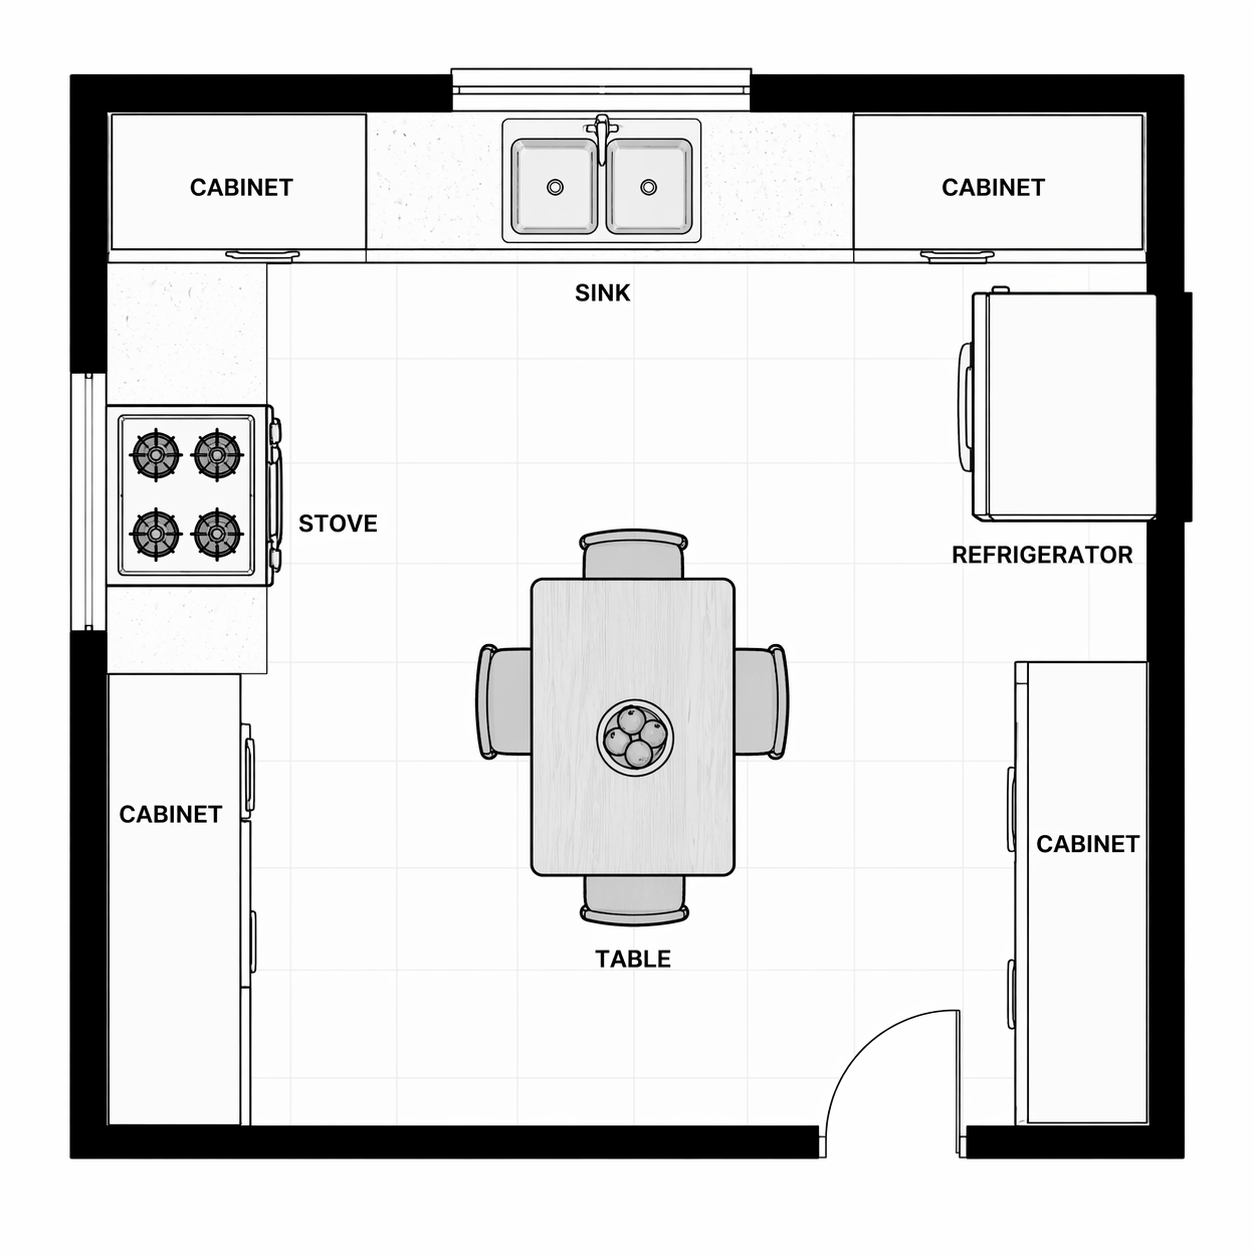

In [2]:
kitchen_path = Path("images/kitchen.png")
kitchen = Image.open(kitchen_path)

print({"image_size": kitchen.size})
display(kitchen)


In [3]:
spatial_prompt = """
You are evaluating spatial reasoning on a kitchen layout image.
The image size is 1254 by 1254 pixels.
Use the top-left corner as (0, 0).

Return valid JSON only with this schema:
{
  "image_size": {"width": 0, "height": 0},
  "objects": [
    {
      "name": "sink|stove|refrigerator|table|door",
      "center_xy": [0, 0],
      "bbox_xyxy": [0, 0, 0, 0],
      "confidence": 0.0,
      "notes": "short note"
    }
  ],
  "limitations": ["short strings"]
}

Use your best estimate, but do not pretend the coordinates are exact.
"""


In [4]:
phase4_response = client.responses.create(
    model="gpt-4o",
    temperature=0,
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": spatial_prompt},
                {
                    "type": "input_image",
                    "image_url": image_to_data_url(kitchen_path),
                    "detail": "high",
                },
            ],
        }
    ],
)

phase4_text = phase4_response.output_text
phase4_json = parse_json_response(phase4_text)
phase4_usage = usage_to_dict(phase4_response.usage)

print("Usage:", phase4_usage)
print(json.dumps(phase4_json, indent=2))


Usage: {'input_tokens': 933, 'output_tokens': 338, 'total_tokens': 1271}
{
  "image_size": {
    "width": 1254,
    "height": 1254
  },
  "objects": [
    {
      "name": "sink",
      "center_xy": [
        627,
        100
      ],
      "bbox_xyxy": [
        500,
        50,
        754,
        150
      ],
      "confidence": 0.9,
      "notes": "Centered at top"
    },
    {
      "name": "stove",
      "center_xy": [
        150,
        300
      ],
      "bbox_xyxy": [
        50,
        250,
        250,
        350
      ],
      "confidence": 0.9,
      "notes": "Left side"
    },
    {
      "name": "refrigerator",
      "center_xy": [
        1050,
        300
      ],
      "bbox_xyxy": [
        950,
        250,
        1150,
        350
      ],
      "confidence": 0.9,
      "notes": "Right side"
    },
    {
      "name": "table",
      "center_xy": [
        627,
        627
      ],
      "bbox_xyxy": [
        500,
        500,
        754,
        754
      ],

[
  {
    "name": "sink",
    "predicted": [
      627,
      100
    ],
    "reference": [
      627,
      134
    ],
    "dx": 0,
    "dy": -34,
    "pixel_error": 34.0
  },
  {
    "name": "stove",
    "predicted": [
      150,
      300
    ],
    "reference": [
      162,
      452
    ],
    "dx": -12,
    "dy": -152,
    "pixel_error": 152.5
  },
  {
    "name": "refrigerator",
    "predicted": [
      1050,
      300
    ],
    "reference": [
      1056,
      421
    ],
    "dx": -6,
    "dy": -121,
    "pixel_error": 121.1
  },
  {
    "name": "table",
    "predicted": [
      627,
      627
    ],
    "reference": [
      627,
      732
    ],
    "dx": 0,
    "dy": -105,
    "pixel_error": 105.0
  },
  {
    "name": "door",
    "predicted": [
      1050,
      1050
    ],
    "reference": [
      975,
      1123
    ],
    "dx": 75,
    "dy": -73,
    "pixel_error": 104.7
  }
]


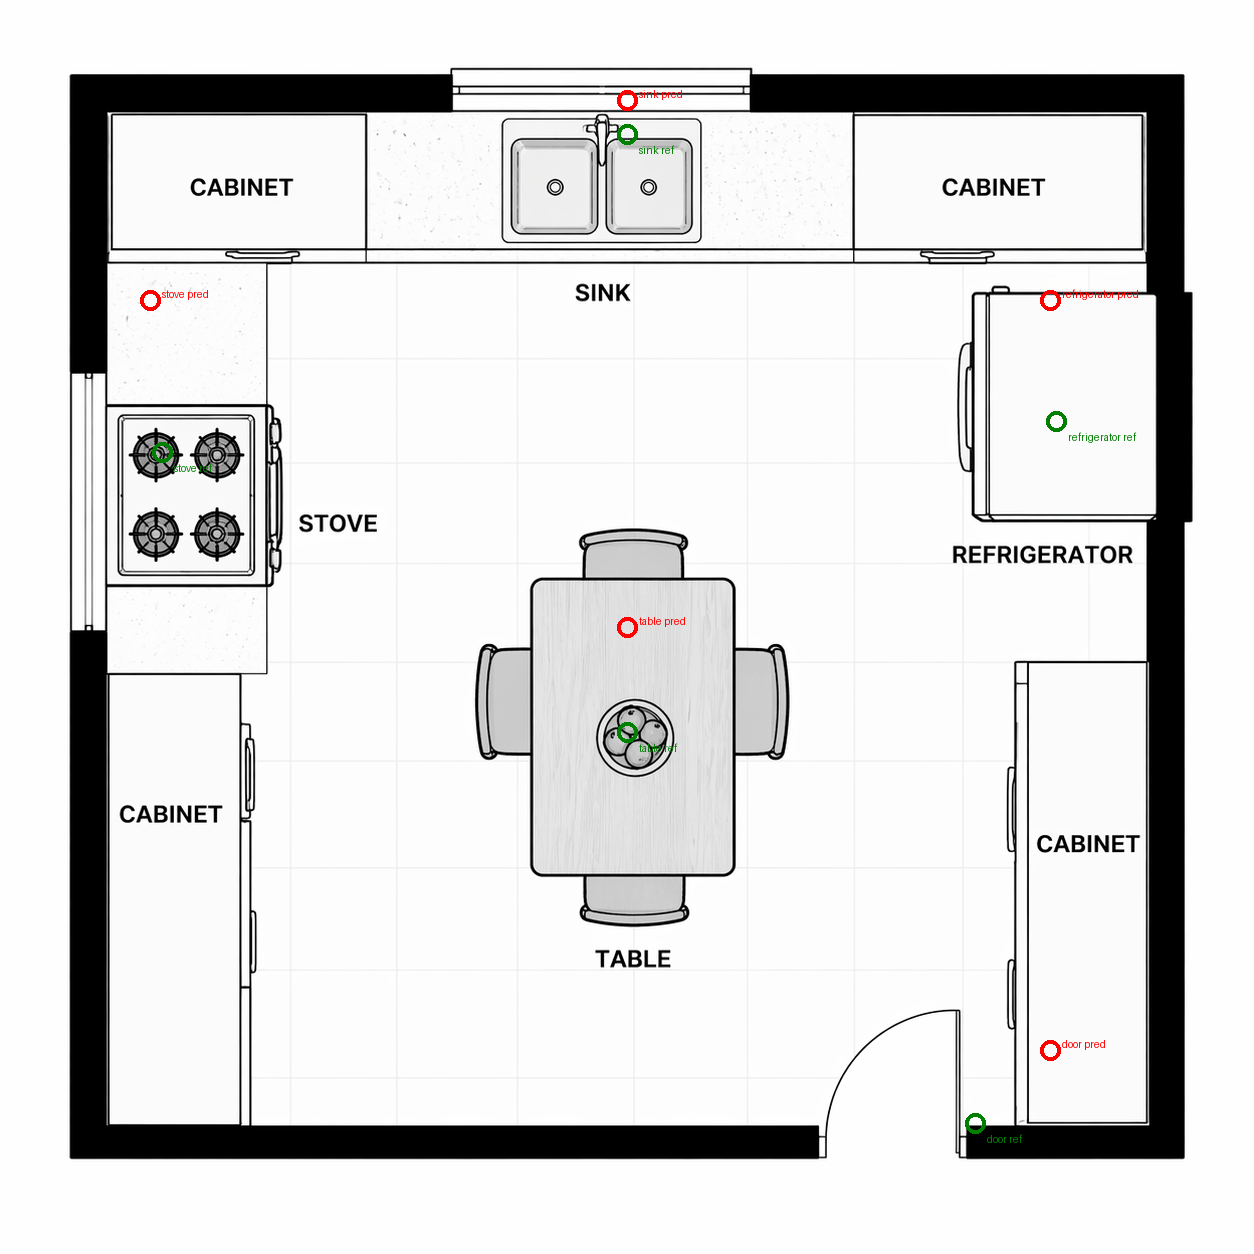

In [5]:
reference_points = {
    "sink": (627, 134),
    "stove": (162, 452),
    "refrigerator": (1056, 421),
    "table": (627, 732),
    "door": (975, 1123),
}

comparison_rows = []
overlay = kitchen.copy()
draw = ImageDraw.Draw(overlay)

for item in phase4_json["objects"]:
    name = item["name"]
    predicted = tuple(item["center_xy"])
    reference = reference_points[name]
    dx = predicted[0] - reference[0]
    dy = predicted[1] - reference[1]
    distance = round((dx ** 2 + dy ** 2) ** 0.5, 1)
    comparison_rows.append(
        {
            "name": name,
            "predicted": predicted,
            "reference": reference,
            "dx": dx,
            "dy": dy,
            "pixel_error": distance,
        }
    )

    draw.ellipse((predicted[0] - 10, predicted[1] - 10, predicted[0] + 10, predicted[1] + 10), outline="red", width=4)
    draw.text((predicted[0] + 12, predicted[1] - 12), f"{name} pred", fill="red")
    draw.ellipse((reference[0] - 10, reference[1] - 10, reference[0] + 10, reference[1] + 10), outline="green", width=4)
    draw.text((reference[0] + 12, reference[1] + 10), f"{name} ref", fill="green")

overlay_path = Path("images/kitchen_spatial_overlay.png")
overlay.save(overlay_path)

print(json.dumps(comparison_rows, indent=2))
display(overlay)


## Answers

**Do the predicted coordinates align perfectly with the image?**

No. They are in the right neighborhood, but not pixel-perfect. The sink was the closest point. The table center still came back more than 100 pixels too high, and the stove, refrigerator, and door all drifted enough to be a real problem for exact box placement. That is good enough for rough semantic localization and bad for anything that needs exact geometry.

**Why do LLMs struggle with exact pixel-level geometry?**

Because they are not reading the image as a crisp CAD grid. The model is turning the image into internal visual tokens, then reasoning over that compressed representation. That is great for "what is this object?" and weak for "give me the exact center at pixel `(975, 1123)`."

**Why is `gpt-4o` not suitable for precise redaction tasks?**

Precise redaction needs guarantees. If a model is even a little off on a bounding box, private data can leak. The kitchen test is a harmless example of the same problem: the model knows what the door is, but its coordinates still drift. That is not the kind of error budget you want on PII redaction.

**Why is Textract not suitable for semantic understanding?**

Textract-style tools are strong when the job is "find text blocks, forms, cells, and coordinates." They are much weaker at page-level meaning. They will give you boxes around words and tables, but they will not naturally reason that a handwritten margin note changes the meaning of a report, or that a credentials box should be treated as sensitive context instead of just another text region.
